In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [18]:
df = pd.read_csv("../data/processed/processed_sports_injury_data.csv")
df.head()# Drop any unneeded row index columns if present


,Unnamed: 0,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,playing_surface,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,sport_type,gender,age,bmi
0,0,72.304051,37.048668,76.481477,5.466370,77.899691,0.375825,10.000000,126.480118,2.654327,...,0,5.678475,79.106564,548.417962,45.028687,0,Basketball,Female,18,25.105748
1,1,40.000000,36.929536,72.363938,6.899090,74.845323,0.279165,310.293156,157.631630,3.431107,...,1,6.411926,116.954654,538.043815,42.254717,2,Basketball,Female,18,25.105748
2,2,76.174609,36.334841,100.000000,9.574152,83.538316,0.334061,158.659094,81.766287,0.800000,...,1,6.643242,96.354742,647.784339,61.870056,0,Basketball,Female,18,25.105748
3,3,100.543724,37.244474,86.172473,7.614297,79.966618,0.218766,107.079298,113.023701,1.713869,...,0,6.194427,97.619130,336.553431,50.268845,0,Basketball,Female,18,25.105748
4,4,78.001235,36.510766,83.195889,5.631979,56.945979,0.484086,164.347133,112.814695,2.154233,...,0,5.835804,83.155527,496.076352,29.233575,2,Basketball,Female,18,25.105748


In [19]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()

Dataset Dimensions: 15420 rows, 27 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   heart_rate             15420 non-null  float64
 1   body_temperature       15420 non-null  float64
 2   hydration_level        15420 non-null  float64
 3   sleep_quality          15420 non-null  float64
 4   recovery_score         15420 non-null  float64
 5   stress_level           15420 non-null  float64
 6   muscle_activity        15420 non-null  float64
 7   joint_angles           15420 non-null  float64
 8   gait_speed             15420 non-null  float64
 9   cadence                15420 non-null  float64
 10  step_count             15420 non-null  int64  
 11  jump_height            15420 non-null  float64
 12  ground_reaction_force  15420 non-null  float64
 13  range_of_motion        15420 non-null  float64
 14  ambient_tem

In [20]:
print("--- Summary Statistics for Core Physiological and Workload Variables ---")
core_metrics = ['heart_rate', 'body_temperature', 'hydration_level', 'sleep_quality', 
                'stress_level', 'training_load', 'fatigue_index', 'recovery_score']
display(df[core_metrics].describe().T)

--- Summary Statistics for Core Physiological and Workload Variables ---


,count,mean,std,min,25%,50%,75%,max
heart_rate,15420.0,72.679456,17.554040,40.000000,60.416589,72.304051,84.475495,159.270125
body_temperature,15420.0,37.106443,0.594843,35.800000,36.698612,37.107090,37.512165,39.200000
hydration_level,15420.0,78.040211,11.699523,45.000000,70.134284,78.165927,86.245543,100.000000
sleep_quality,15420.0,5.815454,1.785390,1.155807,4.559585,5.755650,7.024223,10.000000
stress_level,15420.0,0.422916,0.173425,0.100000,0.300472,0.421168,0.543678,0.950000
training_load,15420.0,670.534269,328.288466,150.000000,426.148857,645.225337,879.607967,2632.637547
fatigue_index,15420.0,59.698315,25.196238,15.000000,41.717110,57.340187,75.186924,270.193219
recovery_score,15420.0,55.202220,17.326338,8.902584,42.321722,54.421403,67.375690,98.000000


In [21]:
print("\n--- Value Counts for Injury Occurred Status ---")
# 0: Healthy, 1: Low Risk, 2: High Risk/Injured
display(df['injury_occurred'].value_counts(normalize=True) * 100)


--- Value Counts for Injury Occurred Status ---


injury_occurred
0    63.994812
1    20.998703
2    15.006485
Name: proportion, dtype: float64

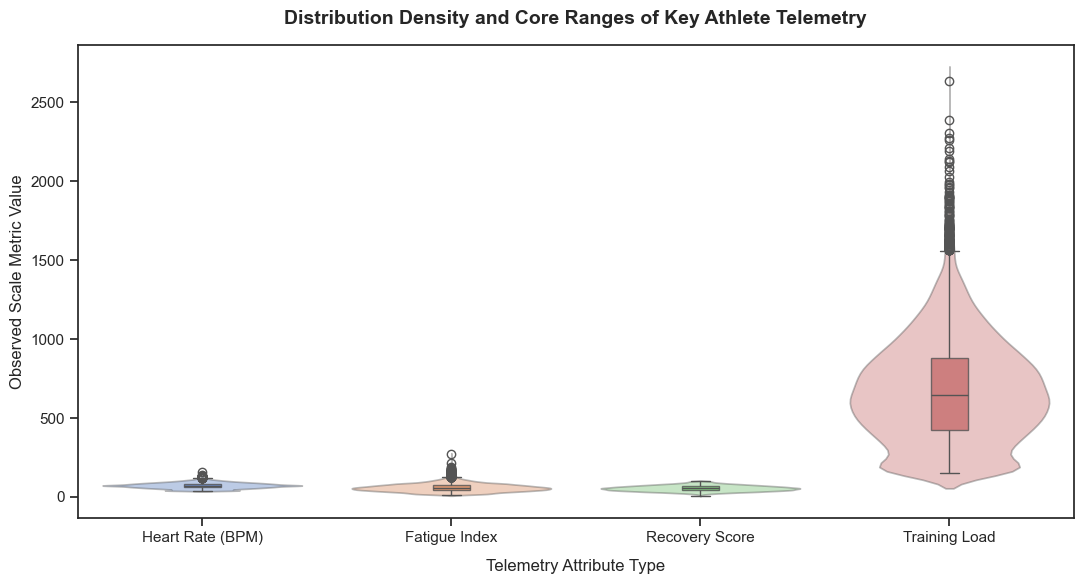

In [22]:
# Cell 3: Visualization 1 - Dispersion and Density of Core Telemetry
# Standardizing key metrics onto a common scale for clean distribution comparison
features_to_compare = ['heart_rate', 'fatigue_index', 'recovery_score', 'training_load']
df_melted = pd.melt(df, value_vars=features_to_compare, var_name='Metric', value_name='Value')

plt.figure(figsize=(11, 6))

# Draw the distribution shapes
sns.violinplot(data=df_melted, x='Metric', y='Value', hue='Metric', 
               palette='muted', inner=None, alpha=0.4, legend=False)

# Overlay narrow box plots to explicitly mark medians and IQR ranges
sns.boxplot(data=df_melted, x='Metric', y='Value', hue='Metric',
            palette='muted', width=0.15, boxprops=dict(alpha=0.8), color='black', legend=False)

plt.title("Distribution Density and Core Ranges of Key Athlete Telemetry", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Telemetry Attribute Type", fontsize=12, labelpad=10)
plt.ylabel("Observed Scale Metric Value", fontsize=12)
plt.xticks(ticks=range(len(features_to_compare)), labels=["Heart Rate (BPM)", "Fatigue Index", "Recovery Score", "Training Load"])

plt.tight_layout()
plt.show()

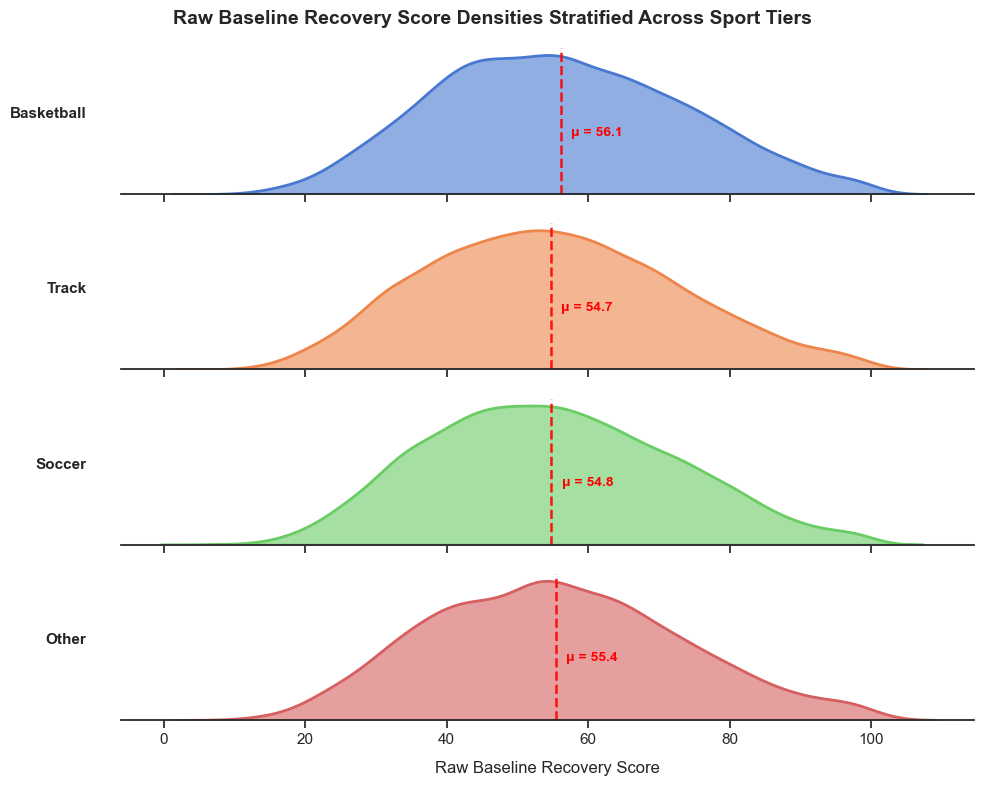

In [56]:
# Assuming df is already loaded from 'multimodal_sports_injury_dataset.csv'
unique_sports = df['sport_type'].unique()
pal = sns.color_palette("muted", len(unique_sports))

fig, axes = plt.subplots(len(unique_sports), 1, figsize=(10, 2 * len(unique_sports)), sharex=True)

for i, sport in enumerate(unique_sports):
    sport_data = df[df['sport_type'] == sport]['recovery_score']
    
    # Calculate the mean value for the current sport category
    sport_mean = sport_data.mean()
    
    # Kernel Density Estimate
    sns.kdeplot(sport_data, fill=True, ax=axes[i], color=pal[i], alpha=0.6, linewidth=2)
    
    # ADDED: Red dashed line to detect the mean recovery score
    axes[i].axvline(
        x=sport_mean, 
        color='red', 
        linestyle='--', 
        linewidth=1.8, 
        alpha=0.9,
        label=f'Mean ({sport_mean:.1f})'
    )
    
    # Optional: Display the mean value as text next to the line for extra clarity
    # We position it slightly to the right of the mean line near the top of each ridge
    ylim = axes[i].get_ylim()
    axes[i].text(
        x=sport_mean + 1.5, 
        y=ylim[1] * 0.4, 
        s=f"μ = {sport_mean:.1f}", 
        color='red', 
        fontweight='bold', 
        fontsize=10
    )
    
    # Clean the axes to create a clean, overlapping ridge appearance
    axes[i].set_ylabel(sport, rotation=0, fontsize=11, fontweight='bold', labelpad=25, ha='right')
    axes[i].set_yticks([])
    sns.despine(ax=axes[i], left=True)
    
    # Plot baseline lines
    axes[i].axhline(0, color='gray', clip_on=False, alpha=0.4, linewidth=1.5)

plt.xlabel("Raw Baseline Recovery Score", fontsize=12, labelpad=10)
plt.suptitle("Raw Baseline Recovery Score Densities Stratified Across Sport Tiers", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

# Adjust the vertical spacing slightly to accommodate the clean ridge look
plt.subplots_adjust(hspace=0.2)



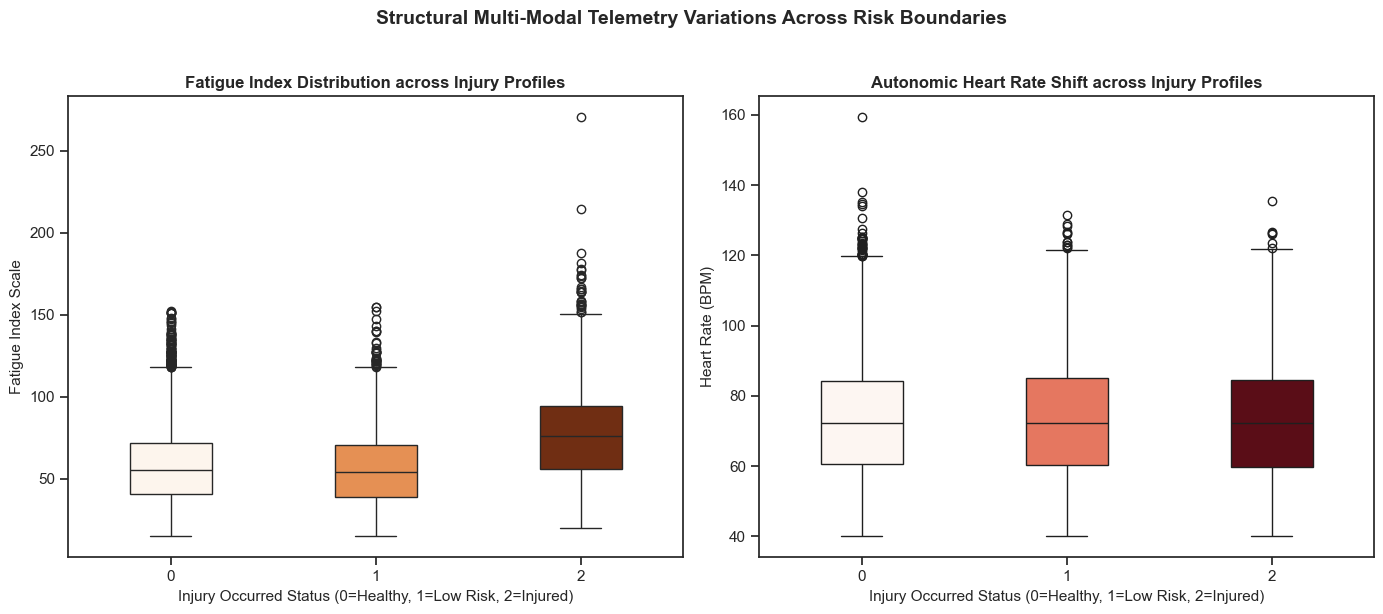

In [25]:
# Cell 5: Visualization 3 - Non-Linear Strain Marker Variance by Injury State
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot A: Fatigue Index vs Injury Occurred
sns.boxplot(data=df, x='injury_occurred', y='fatigue_index', hue='injury_occurred',
            palette='Oranges', width=0.4, ax=axes[0], legend=False)
axes[0].set_title("Fatigue Index Distribution across Injury Profiles", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Injury Occurred Status (0=Healthy, 1=Low Risk, 2=Injured)", fontsize=11)
axes[0].set_ylabel("Fatigue Index Scale", fontsize=11)

# Subplot B: Heart Rate vs Injury Occurred
sns.boxplot(data=df, x='injury_occurred', y='heart_rate', hue='injury_occurred',
            palette='Reds', width=0.4, ax=axes[1], legend=False)
axes[1].set_title("Autonomic Heart Rate Shift across Injury Profiles", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Injury Occurred Status (0=Healthy, 1=Low Risk, 2=Injured)", fontsize=11)
axes[1].set_ylabel("Heart Rate (BPM)", fontsize=11)

plt.suptitle("Structural Multi-Modal Telemetry Variations Across Risk Boundaries", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
from scipy import stats

print("--- Inferential Statistical Tests (Kruskal-Wallis H-Test) ---")

# Hypothesis Definition:
# H0: The distribution of the metric is identical across all three injury risk groups.
# H1: The distribution of the metric shifts significantly in at least one injury group.

test_features = ['fatigue_index', 'heart_rate', 'recovery_score', 'muscle_activity']

for feature in test_features:
    group_0 = df[df['injury_occurred'] == 0][feature]
    group_1 = df[df['injury_occurred'] == 1][feature]
    group_2 = df[df['injury_occurred'] == 2][feature]
    
    stat, p_val = stats.kruskal(group_0, group_1, group_2)
    
    print(f"\nFeature evaluated: {feature}")
    print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
    print(f"p-value: {p_val:.4e}")
    
    if p_val < 0.05:
        print("Outcome: Reject H0. There is a statistically significant variance between populations.")
    else:
        print("Outcome: Fail to reject H0. No statistically significant variance observed.")

--- Inferential Statistical Tests (Kruskal-Wallis H-Test) ---

Feature evaluated: fatigue_index
Kruskal-Wallis H-statistic: 943.2576
p-value: 1.4935e-205
Outcome: Reject H0. There is a statistically significant variance between populations.

Feature evaluated: heart_rate
Kruskal-Wallis H-statistic: 0.0956
p-value: 9.5334e-01
Outcome: Fail to reject H0. No statistically significant variance observed.

Feature evaluated: recovery_score
Kruskal-Wallis H-statistic: 2746.2006
p-value: 0.0000e+00
Outcome: Reject H0. There is a statistically significant variance between populations.

Feature evaluated: muscle_activity
Kruskal-Wallis H-statistic: 0.2912
p-value: 8.6450e-01
Outcome: Fail to reject H0. No statistically significant variance observed.


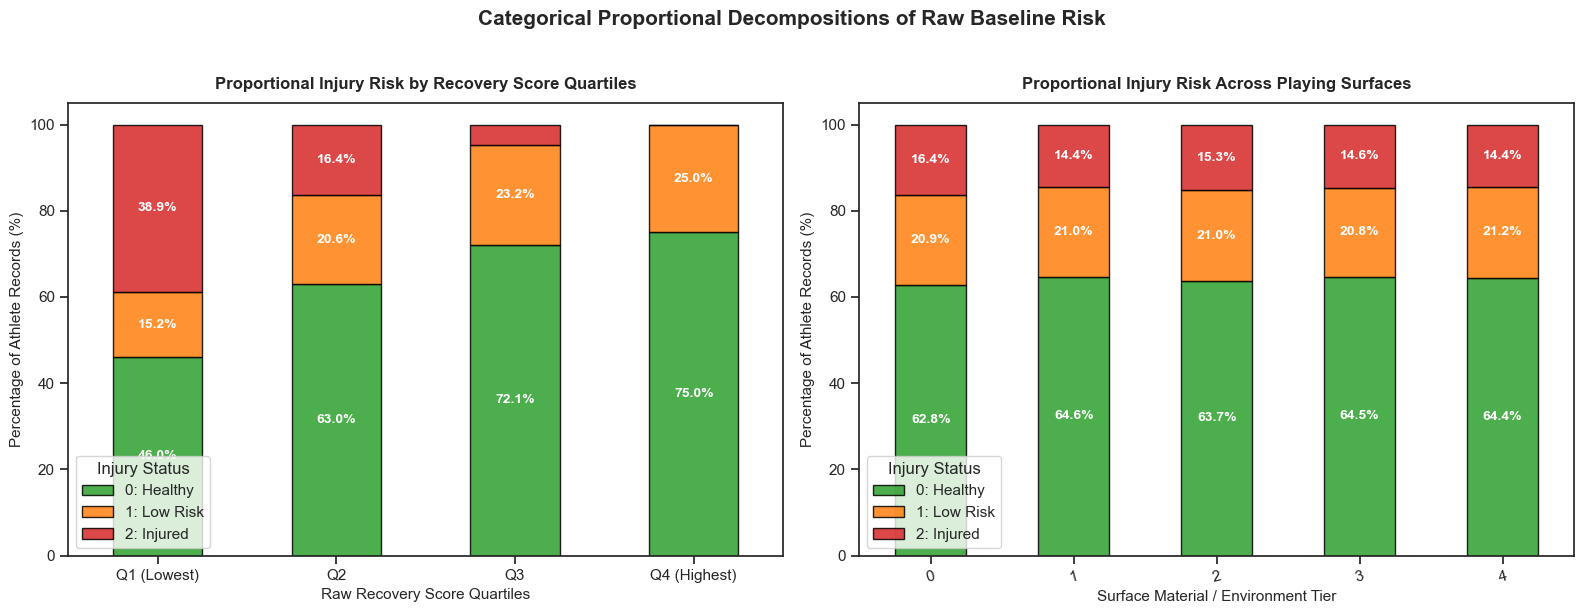

In [28]:
# Cell 8: Proportional Stacked Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------------
# Graph A: 100% Stacked Bar Chart - Recovery Score Quartiles vs Injury Risk
# -------------------------------------------------------------------------
# Bin the continuous recovery score into 4 equal population quartiles
df['recovery_score_quartile'] = pd.qcut(df['recovery_score'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

# Calculate the cross-tabulation proportions
quartile_cross_tab = pd.crosstab(df['recovery_score_quartile'], df['injury_occurred'], normalize='index') * 100

# Plot Stacked Bar
quartile_cross_tab.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ca02c', '#ff7f0e', '#d62728'], edgecolor='black', alpha=0.85)
axes[0].set_title("Proportional Injury Risk by Recovery Score Quartiles", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Raw Recovery Score Quartiles", fontsize=11)
axes[0].set_ylabel("Percentage of Athlete Records (%)", fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title="Injury Status", labels=["0: Healthy", "1: Low Risk", "2: Injured"], loc='lower left')

# Annotate percentages directly onto the stacked segments
for p in axes[0].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Only show labels for segments large enough to display text cleanly
        axes[0].text(x + width/2, y + height/2, f"{height:.1f}%", 
                     ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# -------------------------------------------------------------------------
# Graph B: 100% Stacked Bar Chart - Playing Surface Environment vs Injury Risk
# -------------------------------------------------------------------------
# Calculate the cross-tabulation proportions for environmental surfaces
surface_cross_tab = pd.crosstab(df['playing_surface'], df['injury_occurred'], normalize='index') * 100

# Plot Stacked Bar
surface_cross_tab.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ca02c', '#ff7f0e', '#d62728'], edgecolor='black', alpha=0.85)
axes[1].set_title("Proportional Injury Risk Across Playing Surfaces", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("Surface Material / Environment Tier", fontsize=11)
axes[1].set_ylabel("Percentage of Athlete Records (%)", fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(title="Injury Status", labels=["0: Healthy", "1: Low Risk", "2: Injured"], loc='lower left')

# Annotate percentages directly onto the stacked segments
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5:
        axes[1].text(x + width/2, y + height/2, f"{height:.1f}%", 
                     ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.suptitle("Categorical Proportional Decompositions of Raw Baseline Risk", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Clean up temporary column to keep dataframe pristine
df = df.drop(columns=['recovery_score_quartile'])

Text(0, 0.5, 'Count')

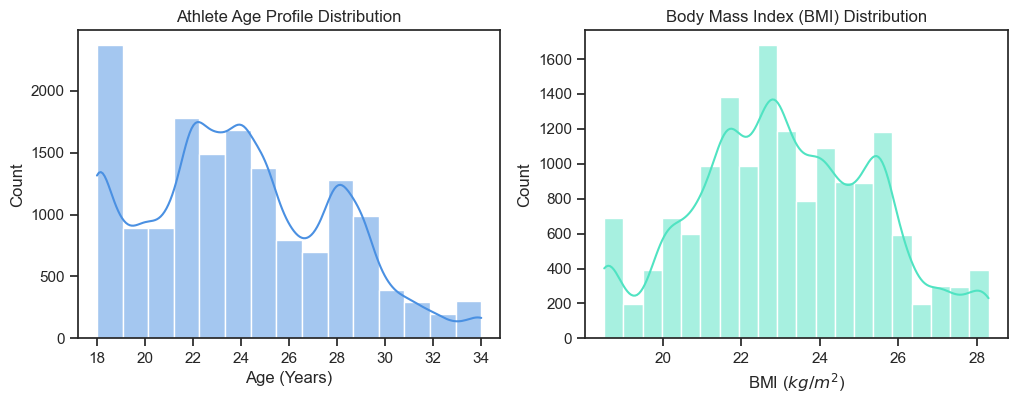

In [55]:
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4))

# Plot A: Age Distribution
sns.histplot(df['age'], kde=True, ax=axes1[0], color='#4A90E2', bins=15)
axes1[0].set_title('Athlete Age Profile Distribution')
axes1[0].set_xlabel('Age (Years)')
axes1[0].set_ylabel('Count')

# Plot B: BMI Distribution
sns.histplot(df['bmi'], kde=True, ax=axes1[1], color='#50E3C2', bins=20)
axes1[1].set_title('Body Mass Index (BMI) Distribution')
axes1[1].set_xlabel('BMI ($kg/m^2$)')
axes1[1].set_ylabel('Count')




Text(0, 0.5, 'Count')

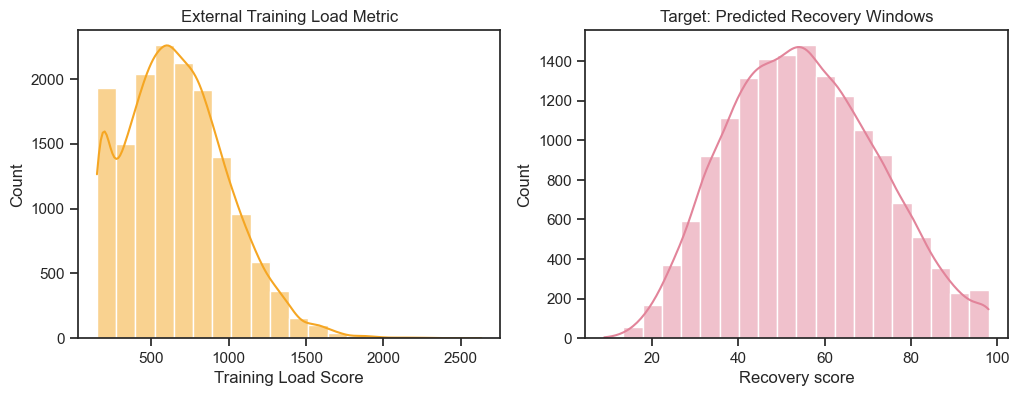

In [57]:
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4))
# Plot C: Training Load
sns.histplot(df['training_load'], kde=True, ax=axes1[0], color='#F5A623', bins=20)
axes1[0].set_title('External Training Load Metric')
axes1[0].set_xlabel('Training Load Score')
axes1[0].set_ylabel('Count')

# Plot D: Target Variable
sns.histplot(df['recovery_score'], kde=True, ax=axes1[1], color='#E2849A', bins=20)
axes1[1].set_title('Target: Predicted Recovery Windows')
axes1[1].set_xlabel('Recovery score')
axes1[1].set_ylabel('Count')

